### Title: Implement AI security measures to protect against adversarial attacks and data breaches.

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9268 - loss: 0.2561
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9657 - loss: 0.1143
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9761 - loss: 0.0785


In [5]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9682 - loss: 0.1065
Test Accuracy: 0.9682000279426575


In [6]:
image = x_test[0]
label = y_test[0]

noise = np.random.normal(0, 0.1, image.shape)
adversarial_image = image + noise
adversarial_image = np.clip(adversarial_image, 0, 1)

In [7]:
original_pred = model.predict(image.reshape(1,28,28))
adv_pred = model.predict(adversarial_image.reshape(1,28,28))

print("Original Prediction:", np.argmax(original_pred))
print("Adversarial Prediction:", np.argmax(adv_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Original Prediction: 7
Adversarial Prediction: 7


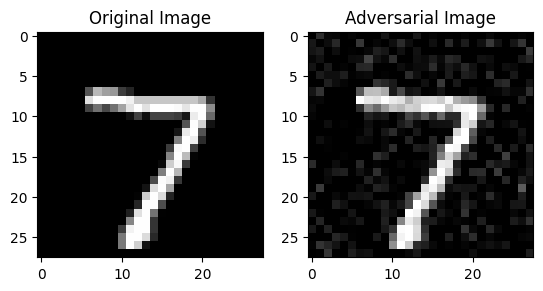

In [8]:
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image, cmap="gray")

plt.subplot(1,2,2)
plt.title("Adversarial Image")
plt.imshow(adversarial_image, cmap="gray")

plt.show()